# Árvores de decisão e métodos ensemble com Titanic
### GCC1734 Inteligência Artificial · Companion da seção 5

Este notebook acompanha a seção 5 das notas de aula 07 usando o conjunto de dados do Titanic via `sklearn.datasets.fetch_openml`.

A ideia é tornar observáveis os conceitos centrais da seção:

- árvores de decisão como particionamento hierárquico do espaço de entradas;
- entropia, impureza e ganho de informação;
- overfitting em árvores profundas;
- controle de complexidade por pré-poda e pós-poda;
- instabilidade de árvores individuais;
- Random Forest e Gradient Boosting como métodos ensemble.

A tarefa é prever `survived`: se uma pessoa sobreviveu ao naufrágio do Titanic.


In [17]:
# Configuração global
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

RNG = np.random.default_rng(42)
np.set_printoptions(precision=3, suppress=True)


---
## 1. Carregamento do Titanic

O dataset vem do OpenML por meio do sklearn. Algumas colunas do Titanic revelam diretamente o desfecho ou só existiriam depois do naufrágio, como `boat` e `body`; elas não são usadas como características.

Usaremos um subconjunto simples e interpretável:

- `pclass`: classe da passagem;
- `sex`: sexo registrado;
- `age`: idade;
- `sibsp`: número de irmãos/cônjuges a bordo;
- `parch`: número de pais/filhos a bordo;
- `fare`: tarifa;
- `embarked`: porto de embarque.


In [18]:
def fetch_titanic_frame(data_home='data/sklearn_openml'):
    try:
        bunch = fetch_openml(name='titanic', version=1, as_frame=True, parser='auto', data_home=data_home)
    except TypeError:
        bunch = fetch_openml(name='titanic', version=1, as_frame=True, data_home=data_home)
    return bunch.frame.copy()


titanic_raw = fetch_titanic_frame()

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

df = titanic_raw[features + [target]].copy()
df['survived'] = df['survived'].astype(int)
df['pclass'] = df['pclass'].astype('category')

print(f'Linhas: {len(df)}')
display(df.head())
display(df.isna().mean().sort_values(ascending=False).to_frame('fração ausente'))


Linhas: 1309


,pclass,sex,age,sibsp,parch,fare,embarked,survived
0,1,female,29.0000,0,0,211.3375,S,1
1,1,male,0.9167,1,2,151.5500,S,1
2,1,female,2.0000,1,2,151.5500,S,0
3,1,male,30.0000,1,2,151.5500,S,0
4,1,female,25.0000,1,2,151.5500,S,0


,fração ausente
age,0.200917
embarked,0.001528
fare,0.000764
pclass,0.000000
sibsp,0.000000
sex,0.000000
parch,0.000000
survived,0.000000


### Distribuição das classes e sinais simples

Antes de treinar qualquer modelo, vale olhar a distribuição do rótulo e relações simples com algumas variáveis. Isso ajuda a interpretar as primeiras divisões da árvore.


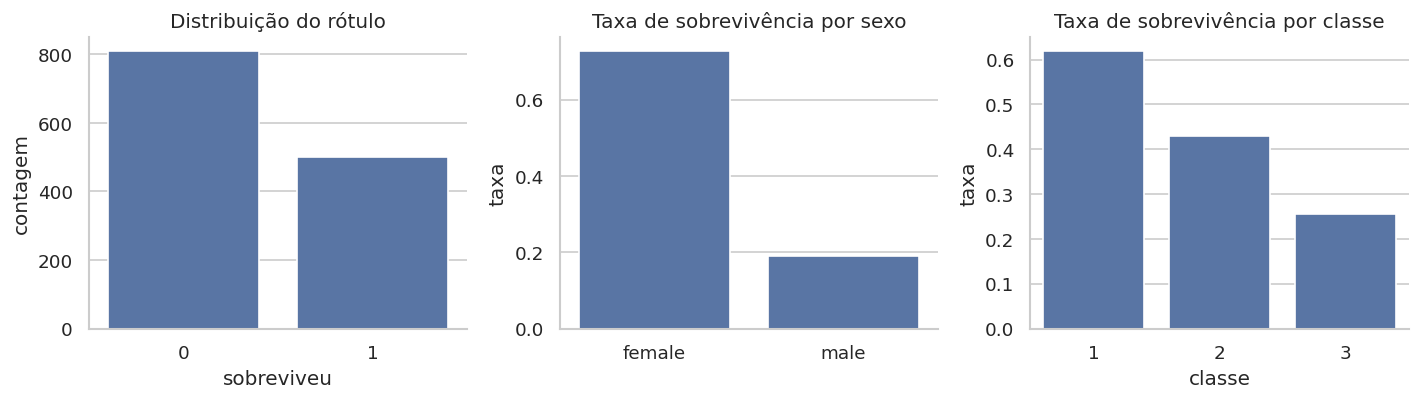

,sobrevivência média,classe majoritária
0,0.381971,0.618029


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

sns.countplot(data=df, x='survived', ax=axes[0])
axes[0].set(title='Distribuição do rótulo', xlabel='sobreviveu', ylabel='contagem')

sns.barplot(data=df, x='sex', y='survived', errorbar=None, ax=axes[1])
axes[1].set(title='Taxa de sobrevivência por sexo', xlabel='', ylabel='taxa')

sns.barplot(data=df, x='pclass', y='survived', errorbar=None, ax=axes[2])
axes[2].set(title='Taxa de sobrevivência por classe', xlabel='classe', ylabel='taxa')

plt.tight_layout()
plt.show()

summary = pd.DataFrame(
    {
        'sobrevivência média': [df['survived'].mean()],
        'classe majoritária': [df['survived'].value_counts(normalize=True).max()],
    }
)
display(summary)


---
## 2. Pré-processamento e primeira árvore

Árvores não exigem padronização numérica como regressão logística ou SVM, mas ainda precisamos lidar com valores ausentes e atributos categóricos. O pipeline abaixo usa imputação e one-hot encoding.

A primeira árvore é rasa (`max_depth=3`) para favorecer interpretação.


In [20]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

numeric_preprocess = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median'))]
)

categorical_preprocess = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', make_one_hot_encoder()),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_preprocess, numeric_features),
        ('cat', categorical_preprocess, categorical_features),
    ]
)

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

shallow_tree = Pipeline(
    steps=[
        ('preprocess', preprocess),
        ('clf', DecisionTreeClassifier(
            criterion='entropy',
            max_depth=3,
            min_samples_leaf=20,
            random_state=42,
        )),
    ]
)

shallow_tree.fit(X_train, y_train)
pred = shallow_tree.predict(X_test)
proba = shallow_tree.predict_proba(X_test)[:, 1]

metrics_shallow = pd.DataFrame(
    [
        {
            'modelo': 'árvore rasa',
            'acurácia': accuracy_score(y_test, pred),
            'acurácia balanceada': balanced_accuracy_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'ROC AUC': roc_auc_score(y_test, proba),
            'profundidade': shallow_tree.named_steps['clf'].get_depth(),
            'folhas': shallow_tree.named_steps['clf'].get_n_leaves(),
        }
    ]
)
metrics_shallow


,modelo,acurácia,acurácia balanceada,F1,ROC AUC,profundidade,folhas
0,árvore rasa,0.820122,0.807034,0.761134,0.871015,3,7


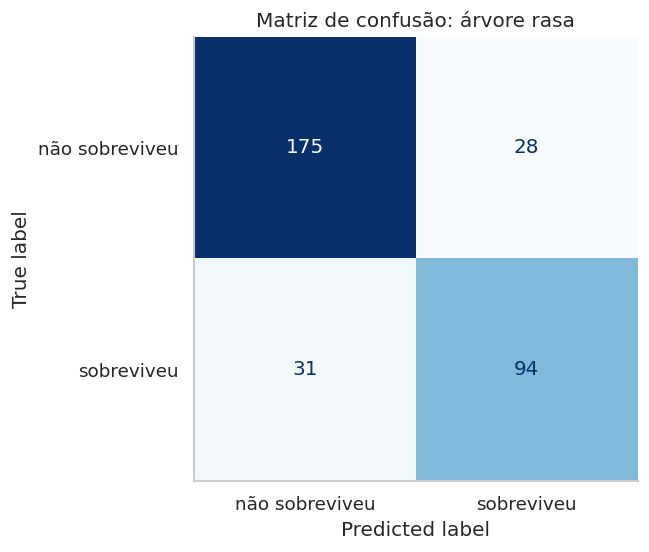

                precision    recall  f1-score   support

não sobreviveu       0.85      0.86      0.86       203
    sobreviveu       0.77      0.75      0.76       125

      accuracy                           0.82       328
     macro avg       0.81      0.81      0.81       328
  weighted avg       0.82      0.82      0.82       328



In [21]:
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm, display_labels=['não sobreviveu', 'sobreviveu']).plot(cmap='Blues', colorbar=False)
plt.title('Matriz de confusão: árvore rasa')
plt.grid(False)
plt.show()

print(classification_report(y_test, pred, target_names=['não sobreviveu', 'sobreviveu']))


### Visualização da árvore

Cada nó interno testa uma condição. Cada folha guarda uma previsão baseada na distribuição das classes entre os exemplos que chegaram ali.


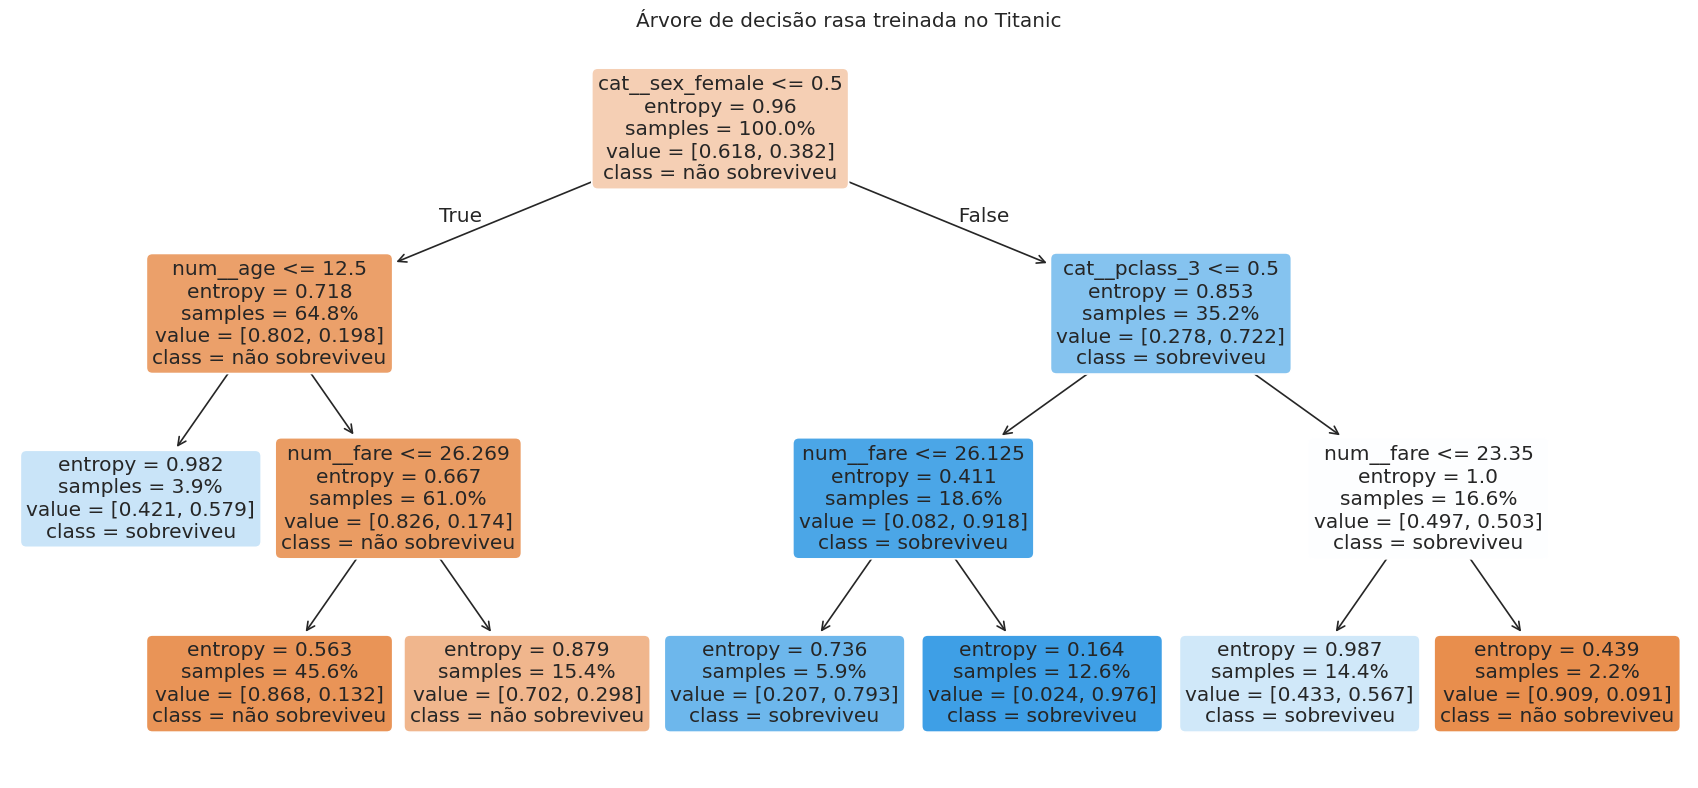

In [22]:
feature_names = shallow_tree.named_steps['preprocess'].get_feature_names_out()
clf = shallow_tree.named_steps['clf']

plt.figure(figsize=(18, 8))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=['não sobreviveu', 'sobreviveu'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=True,
)
plt.title('Árvore de decisão rasa treinada no Titanic')
plt.show()


In [23]:
print(export_text(clf, feature_names=list(feature_names), max_depth=3))


|--- cat__sex_female <= 0.50
|   |--- num__age <= 12.50
|   |   |--- class: 1
|   |--- num__age >  12.50
|   |   |--- num__fare <= 26.27
|   |   |   |--- class: 0
|   |   |--- num__fare >  26.27
|   |   |   |--- class: 0
|--- cat__sex_female >  0.50
|   |--- cat__pclass_3 <= 0.50
|   |   |--- num__fare <= 26.12
|   |   |   |--- class: 1
|   |   |--- num__fare >  26.12
|   |   |   |--- class: 1
|   |--- cat__pclass_3 >  0.50
|   |   |--- num__fare <= 23.35
|   |   |   |--- class: 1
|   |   |--- num__fare >  23.35
|   |   |   |--- class: 0



---
## 3. Entropia e ganho de informação

A seção das notas define entropia como medida de impureza:

$$
H(S) = -\sum_k p_k \log_2 p_k
$$

O ganho de informação mede quanto a divisão reduz a impureza:

$$
IG(S, A) = H(S) - \sum_v \frac{|S_v|}{|S|}H(S_v)
$$

A célula abaixo calcula esse valor manualmente para algumas divisões binárias simples no conjunto de treino.


In [24]:
def entropy(labels):
    labels = pd.Series(labels)
    probs = labels.value_counts(normalize=True)
    return float(-(probs * np.log2(probs)).sum())


def information_gain_binary(y_values, mask_left):
    y_values = pd.Series(y_values).reset_index(drop=True)
    mask_left = pd.Series(mask_left).reset_index(drop=True).astype(bool)
    n = len(y_values)
    h_root = entropy(y_values)
    h_left = entropy(y_values[mask_left])
    h_right = entropy(y_values[~mask_left])
    weighted = mask_left.mean() * h_left + (~mask_left).mean() * h_right
    return {
        'entropia raiz': h_root,
        'entropia esquerda': h_left,
        'entropia direita': h_right,
        'ganho informação': h_root - weighted,
        'n esquerda': int(mask_left.sum()),
        'n direita': int((~mask_left).sum()),
        'taxa esquerda': y_values[mask_left].mean(),
        'taxa direita': y_values[~mask_left].mean(),
    }


candidate_splits = {
    'sex == female': X_train['sex'].astype(str).eq('female'),
    'pclass == 1': X_train['pclass'].astype(str).eq('1'),
    'age < 12': X_train['age'].lt(12).fillna(False),
    'fare >= mediana': X_train['fare'].ge(X_train['fare'].median()).fillna(False),
    'embarked == C': X_train['embarked'].astype(str).eq('C'),
}

ig_rows = []
for name, mask in candidate_splits.items():
    row = information_gain_binary(y_train, mask)
    row['divisão'] = name
    ig_rows.append(row)

ig_table = pd.DataFrame(ig_rows).sort_values('ganho informação', ascending=False)
ig_table[
    ['divisão', 'entropia raiz', 'entropia esquerda', 'entropia direita', 'ganho informação', 'n esquerda', 'n direita', 'taxa esquerda', 'taxa direita']
]


,divisão,entropia raiz,entropia esquerda,entropia direita,ganho informação,n esquerda,n direita,taxa esquerda,taxa direita
0,sex == female,0.959625,0.853070,0.718138,0.194033,345,636,0.721739,0.198113
1,pclass == 1,0.959625,0.965867,0.892064,0.049505,240,741,0.608333,0.309042
3,fare >= mediana,0.959625,0.999892,0.824711,0.047412,490,491,0.506122,0.258656
4,embarked == C,0.959625,0.983708,0.917868,0.028333,200,781,0.575000,0.332907
2,age < 12,0.959625,0.986126,0.949898,0.007326,65,916,0.569231,0.368996


---
## 4. Profundidade, erro de treino e erro de teste

Árvores profundas conseguem criar muitas regiões pequenas. Isso reduz o erro de treino, mas pode capturar ruído e detalhes específicos da amostra. O experimento abaixo varia `max_depth` e compara desempenho em treino e teste.


,max_depth,profundidade real,folhas,acurácia treino,acurácia teste,F1 teste
0,1,1,2,0.773700,0.798780,0.731707
1,2,2,4,0.779817,0.792683,0.736434
2,3,3,8,0.811417,0.832317,0.773663
3,4,4,16,0.818552,0.832317,0.773663
4,5,5,27,0.823649,0.832317,0.773663
5,6,6,38,0.834862,0.829268,0.770492
6,7,7,50,0.847095,0.835366,0.747664
7,8,8,66,0.852192,0.814024,0.762646
8,9,9,88,0.868502,0.823171,0.752137
9,10,10,108,0.888889,0.786585,0.698276


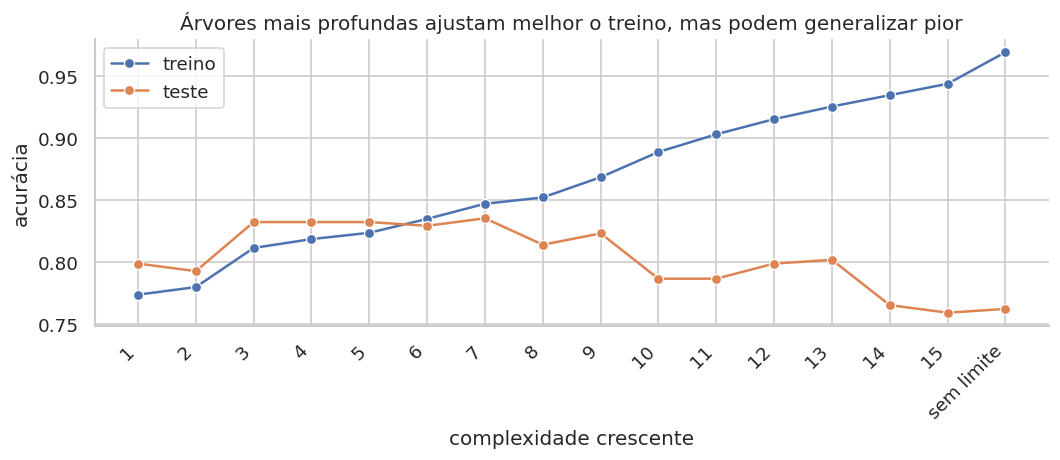

In [25]:
depth_values = list(range(1, 16)) + [None]
rows = []

for depth in depth_values:
    model = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('clf', DecisionTreeClassifier(
                criterion='entropy',
                max_depth=depth,
                random_state=42,
            )),
        ]
    )
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    clf = model.named_steps['clf']
    rows.append(
        {
            'max_depth': 'sem limite' if depth is None else depth,
            'profundidade real': clf.get_depth(),
            'folhas': clf.get_n_leaves(),
            'acurácia treino': accuracy_score(y_train, train_pred),
            'acurácia teste': accuracy_score(y_test, test_pred),
            'F1 teste': f1_score(y_test, test_pred),
        }
    )

depth_results = pd.DataFrame(rows)
display(depth_results)

plot_df = depth_results.copy()
plot_df['complexidade'] = range(len(plot_df))

fig, ax = plt.subplots(figsize=(9, 4))
sns.lineplot(data=plot_df, x='complexidade', y='acurácia treino', marker='o', label='treino', ax=ax)
sns.lineplot(data=plot_df, x='complexidade', y='acurácia teste', marker='o', label='teste', ax=ax)
ax.set(
    title='Árvores mais profundas ajustam melhor o treino, mas podem generalizar pior',
    xlabel='complexidade crescente',
    ylabel='acurácia',
)
ax.set_xticks(plot_df['complexidade'])
ax.set_xticklabels(depth_results['max_depth'], rotation=45, ha='right')
plt.tight_layout()
plt.show()


---
## 5. Pré-poda por validação cruzada

Pré-poda controla a árvore durante a construção. Exemplos de hiperparâmetros:

- `max_depth`: profundidade máxima;
- `min_samples_leaf`: mínimo de exemplos por folha;
- `criterion`: critério local de divisão, como Gini ou entropia.

Aqui usamos validação cruzada para escolher esses valores.


In [26]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    'clf__criterion': ['gini', 'entropy'],
    'clf__max_depth': [2, 3, 4, 5, 6, None],
    'clf__min_samples_leaf': [1, 5, 10, 20, 40],
}

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('clf', DecisionTreeClassifier(random_state=42)),
        ]
    ),
    param_grid=param_grid,
    scoring='balanced_accuracy',
    cv=cv,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_tree = search.best_estimator_
best_pred = best_tree.predict(X_test)
best_proba = best_tree.predict_proba(X_test)[:, 1]

print('Melhores hiperparâmetros:', search.best_params_)
print(f'Melhor acurácia balanceada média em CV: {search.best_score_:.3f}')

pd.DataFrame(
    [
        {
            'modelo': 'árvore com pré-poda via CV',
            'acurácia teste': accuracy_score(y_test, best_pred),
            'acurácia balanceada teste': balanced_accuracy_score(y_test, best_pred),
            'F1 teste': f1_score(y_test, best_pred),
            'ROC AUC teste': roc_auc_score(y_test, best_proba),
            'profundidade': best_tree.named_steps['clf'].get_depth(),
            'folhas': best_tree.named_steps['clf'].get_n_leaves(),
        }
    ]
)


Melhores hiperparâmetros: {'clf__criterion': 'gini', 'clf__max_depth': 3, 'clf__min_samples_leaf': 1}
Melhor acurácia balanceada média em CV: 0.784


,modelo,acurácia teste,acurácia balanceada teste,F1 teste,ROC AUC teste,profundidade,folhas
0,árvore com pré-poda via CV,0.832317,0.816887,0.773663,0.882759,3,8


### Pós-poda por `ccp_alpha`

A pós-poda por complexidade de custo constrói uma árvore grande e depois remove ramos que não compensam a complexidade adicional. No sklearn, isso é controlado por `ccp_alpha`.


,ccp_alpha,profundidade,folhas,acurácia treino,acurácia teste,F1 teste
20,0.003508,10,32,0.844037,0.835366,0.750000
22,0.004822,7,16,0.827727,0.832317,0.775510
23,0.010961,3,8,0.811417,0.832317,0.773663
21,0.004010,7,23,0.828746,0.832317,0.775510
19,0.003206,10,43,0.851172,0.814024,0.764479
18,0.003070,14,61,0.861366,0.798780,0.750000
24,0.057673,1,2,0.773700,0.798780,0.731707
12,0.002408,18,128,0.922528,0.795732,0.737255
14,0.002561,18,95,0.887870,0.795732,0.747170
13,0.002474,18,111,0.906218,0.792683,0.748148


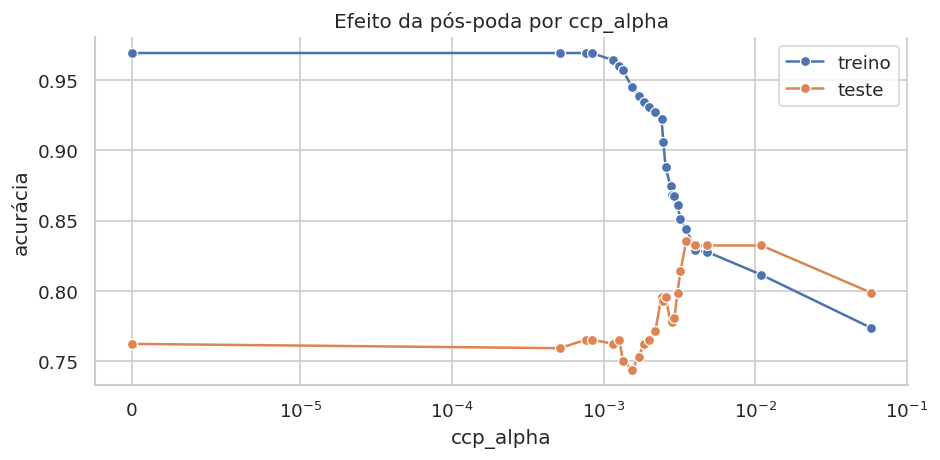

In [27]:
pre_for_pruning = preprocess
X_train_enc = pre_for_pruning.fit_transform(X_train)
X_test_enc = pre_for_pruning.transform(X_test)
encoded_names = pre_for_pruning.get_feature_names_out()

base_for_path = DecisionTreeClassifier(criterion='entropy', random_state=42)
path = base_for_path.cost_complexity_pruning_path(X_train_enc, y_train)
ccp_alphas = path.ccp_alphas[:-1]

if len(ccp_alphas) > 25:
    alpha_grid = np.unique(np.quantile(ccp_alphas, np.linspace(0, 1, 25)))
else:
    alpha_grid = ccp_alphas

pruning_rows = []
for alpha in alpha_grid:
    tree = DecisionTreeClassifier(criterion='entropy', random_state=42, ccp_alpha=float(alpha))
    tree.fit(X_train_enc, y_train)
    pruning_rows.append(
        {
            'ccp_alpha': alpha,
            'profundidade': tree.get_depth(),
            'folhas': tree.get_n_leaves(),
            'acurácia treino': accuracy_score(y_train, tree.predict(X_train_enc)),
            'acurácia teste': accuracy_score(y_test, tree.predict(X_test_enc)),
            'F1 teste': f1_score(y_test, tree.predict(X_test_enc)),
        }
    )

pruning_results = pd.DataFrame(pruning_rows)
display(pruning_results.sort_values('acurácia teste', ascending=False).head(10))

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=pruning_results, x='ccp_alpha', y='acurácia treino', marker='o', label='treino', ax=ax)
sns.lineplot(data=pruning_results, x='ccp_alpha', y='acurácia teste', marker='o', label='teste', ax=ax)
ax.set_xscale('symlog', linthresh=1e-5)
ax.set(title='Efeito da pós-poda por ccp_alpha', xlabel='ccp_alpha', ylabel='acurácia')
plt.tight_layout()
plt.show()


---
## 6. Instabilidade de árvores individuais

A seção das notas destaca que árvores têm alta variância: pequenas mudanças no treino podem produzir árvores diferentes. Vamos treinar várias árvores em amostras bootstrap e observar a dispersão das probabilidades previstas no mesmo conjunto de teste.


Desvio-padrão médio das probabilidades previstas: 0.268
Percentil 90 do desvio-padrão: 0.479


,vezes como primeira divisão
cat__sex_female,35
cat__sex_male,25


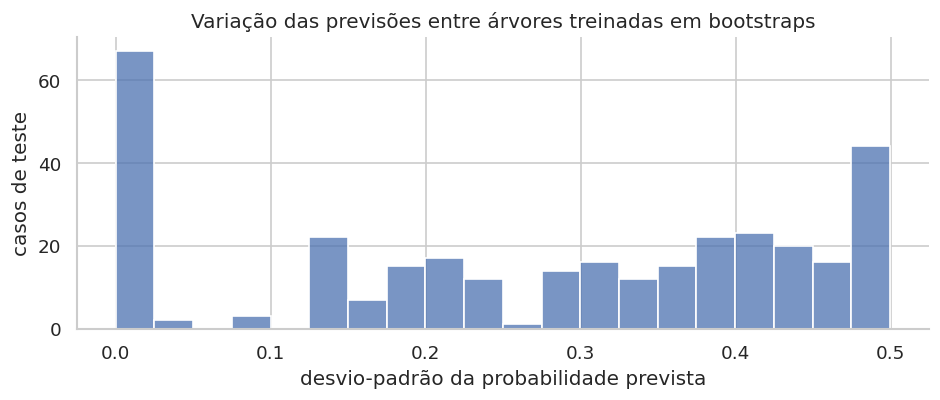

In [28]:
n_bootstrap = 60
single_tree_probs = []
first_split_features = []

for i in range(n_bootstrap):
    sample_idx = RNG.choice(len(X_train), size=len(X_train), replace=True)
    X_boot = X_train.iloc[sample_idx]
    y_boot = y_train.iloc[sample_idx]

    model = Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('clf', DecisionTreeClassifier(criterion='entropy', random_state=i)),
        ]
    )
    model.fit(X_boot, y_boot)
    single_tree_probs.append(model.predict_proba(X_test)[:, 1])

    names = model.named_steps['preprocess'].get_feature_names_out()
    root_feature_idx = model.named_steps['clf'].tree_.feature[0]
    first_split_features.append(names[root_feature_idx] if root_feature_idx >= 0 else 'folha')

single_tree_probs = np.vstack(single_tree_probs)
prob_std = single_tree_probs.std(axis=0)

print(f'Desvio-padrão médio das probabilidades previstas: {prob_std.mean():.3f}')
print(f'Percentil 90 do desvio-padrão: {np.quantile(prob_std, 0.90):.3f}')

display(pd.Series(first_split_features).value_counts().to_frame('vezes como primeira divisão'))

fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(prob_std, bins=20, ax=ax)
ax.set(title='Variação das previsões entre árvores treinadas em bootstraps', xlabel='desvio-padrão da probabilidade prevista', ylabel='casos de teste')
plt.tight_layout()
plt.show()


---
## 7. Ensembles: Random Forest e Gradient Boosting

Random Forest reduz variância combinando muitas árvores treinadas em amostras bootstrap e com subconjuntos aleatórios de atributos. Gradient Boosting treina árvores sequencialmente para corrigir erros do ensemble acumulado.

A comparação abaixo usa o mesmo pré-processamento para todos os modelos.


In [29]:
models = {
    'árvore sem poda': Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('clf', DecisionTreeClassifier(random_state=42)),
        ]
    ),
    'árvore pré-podada': best_tree,
    'Random Forest': Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('clf', RandomForestClassifier(
                n_estimators=300,
                max_features='sqrt',
                min_samples_leaf=3,
                random_state=42,
                n_jobs=-1,
            )),
        ]
    ),
    'Gradient Boosting': Pipeline(
        steps=[
            ('preprocess', preprocess),
            ('clf', GradientBoostingClassifier(
                n_estimators=150,
                learning_rate=0.05,
                max_depth=2,
                random_state=42,
            )),
        ]
    ),
}

model_rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    clf = model.named_steps['clf']
    model_rows.append(
        {
            'modelo': name,
            'acurácia': accuracy_score(y_test, pred),
            'acurácia balanceada': balanced_accuracy_score(y_test, pred),
            'F1': f1_score(y_test, pred),
            'ROC AUC': roc_auc_score(y_test, proba),
            'profundidade': getattr(clf, 'get_depth', lambda: np.nan)(),
            'folhas': getattr(clf, 'get_n_leaves', lambda: np.nan)(),
        }
    )

comparison = pd.DataFrame(model_rows).sort_values('ROC AUC', ascending=False)
comparison


,modelo,acurácia,acurácia balanceada,F1,ROC AUC,profundidade,folhas
2,Random Forest,0.835366,0.816276,0.773109,0.886581,NaN,NaN
3,Gradient Boosting,0.838415,0.820276,0.778243,0.884906,NaN,NaN
1,árvore pré-podada,0.832317,0.816887,0.773663,0.882759,3.0,8.0
0,árvore sem poda,0.746951,0.734089,0.671937,0.737261,20.0,247.0


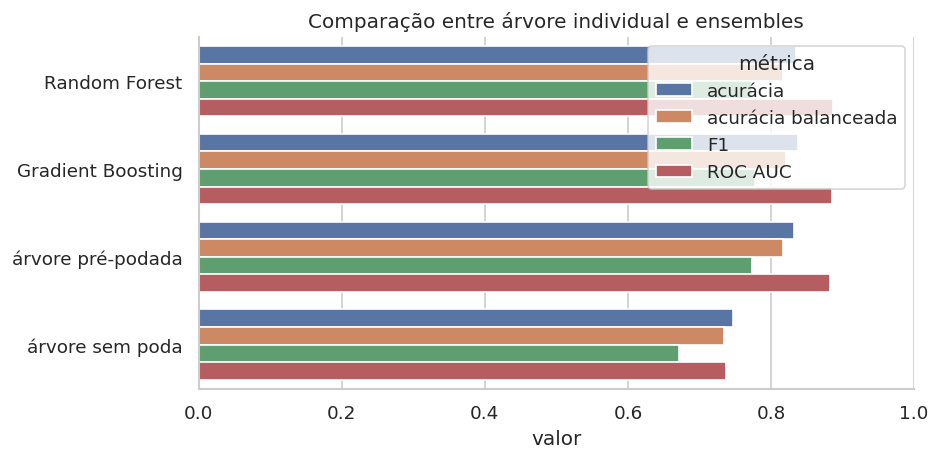

In [30]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_metrics = comparison.melt(
    id_vars='modelo',
    value_vars=['acurácia', 'acurácia balanceada', 'F1', 'ROC AUC'],
    var_name='métrica',
    value_name='valor',
)
sns.barplot(data=plot_metrics, x='valor', y='modelo', hue='métrica', ax=ax)
ax.set(title='Comparação entre árvore individual e ensembles', xlabel='valor', ylabel='')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()


### Importância de características

Árvores e florestas permitem inspecionar quais características foram mais usadas para reduzir impureza. Essa importância não é causal; ela apenas descreve o comportamento do modelo treinado.


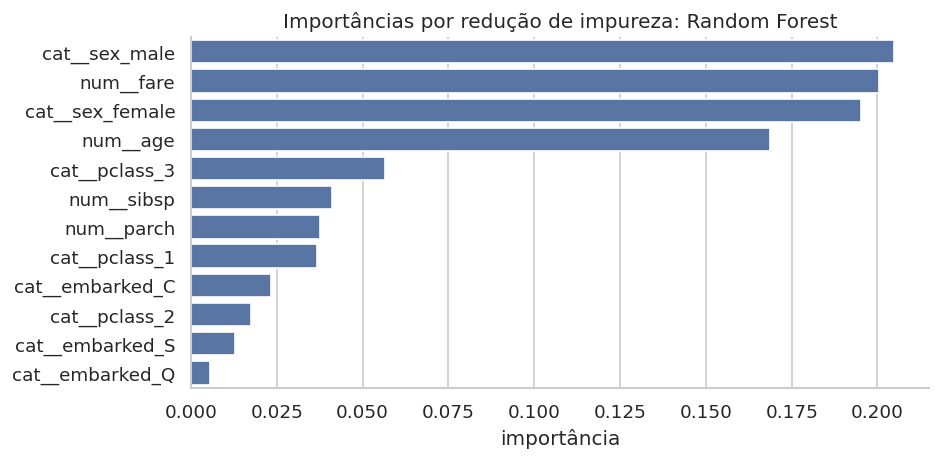

,característica,importância
8,cat__sex_male,0.204712
3,num__fare,0.200514
7,cat__sex_female,0.195250
0,num__age,0.168543
6,cat__pclass_3,0.056522
1,num__sibsp,0.041185
2,num__parch,0.037498
4,cat__pclass_1,0.036659
9,cat__embarked_C,0.023393
5,cat__pclass_2,0.017530


In [31]:
rf_model = models['Random Forest']
rf_model.fit(X_train, y_train)
rf_names = rf_model.named_steps['preprocess'].get_feature_names_out()
rf_importance = pd.DataFrame(
    {
        'característica': rf_names,
        'importância': rf_model.named_steps['clf'].feature_importances_,
    }
).sort_values('importância', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=rf_importance.head(12), x='importância', y='característica', ax=ax)
ax.set(title='Importâncias por redução de impureza: Random Forest', xlabel='importância', ylabel='')
plt.tight_layout()
plt.show()

rf_importance.head(12)


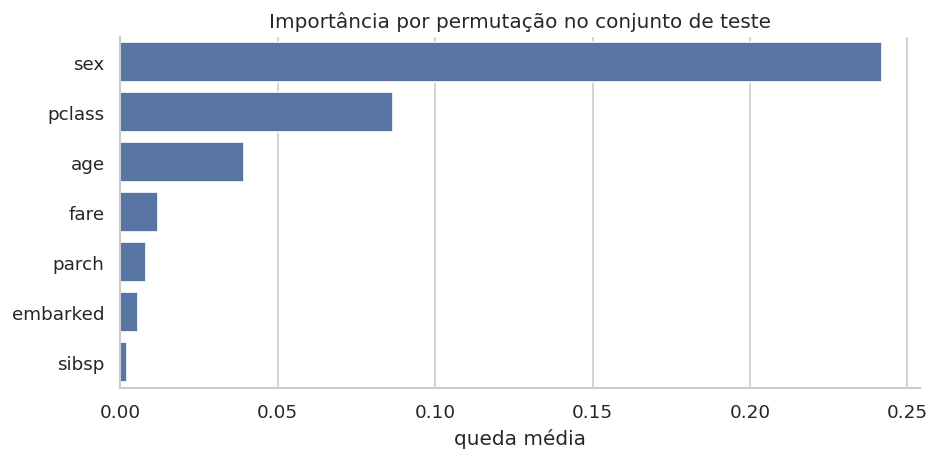

,característica original,queda média na acurácia balanceada,desvio
1,sex,0.241887,0.024664
0,pclass,0.086624,0.011999
2,age,0.039188,0.013730
5,fare,0.011855,0.011305
4,parch,0.008030,0.005600
6,embarked,0.005540,0.008741
3,sibsp,0.002276,0.006504


In [32]:
perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    scoring='balanced_accuracy',
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
)

perm_importance = pd.DataFrame(
    {
        'característica original': features,
        'queda média na acurácia balanceada': perm.importances_mean,
        'desvio': perm.importances_std,
    }
).sort_values('queda média na acurácia balanceada', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=perm_importance, x='queda média na acurácia balanceada', y='característica original', ax=ax)
ax.set(title='Importância por permutação no conjunto de teste', xlabel='queda média', ylabel='')
plt.tight_layout()
plt.show()

perm_importance


---
## Fechamento para sala

Perguntas para conduzir a discussão:

1. Qual foi a primeira divisão mais informativa no Titanic? Ela combina com a tabela de ganho de informação?
2. O que acontece com erro de treino e erro de teste quando aumentamos `max_depth`?
3. Qual a diferença prática entre pré-poda (`max_depth`, `min_samples_leaf`) e pós-poda (`ccp_alpha`)?
4. Por que árvores individuais mudam quando treinadas em amostras bootstrap?
5. Como Random Forest reduz variância em relação a uma única árvore?
6. Por que Gradient Boosting pode ser mais sensível a hiperparâmetros que Random Forest?
7. As importâncias de características provam causalidade? Por quê?
